# Principal Component Analysis(PCA)

c:\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


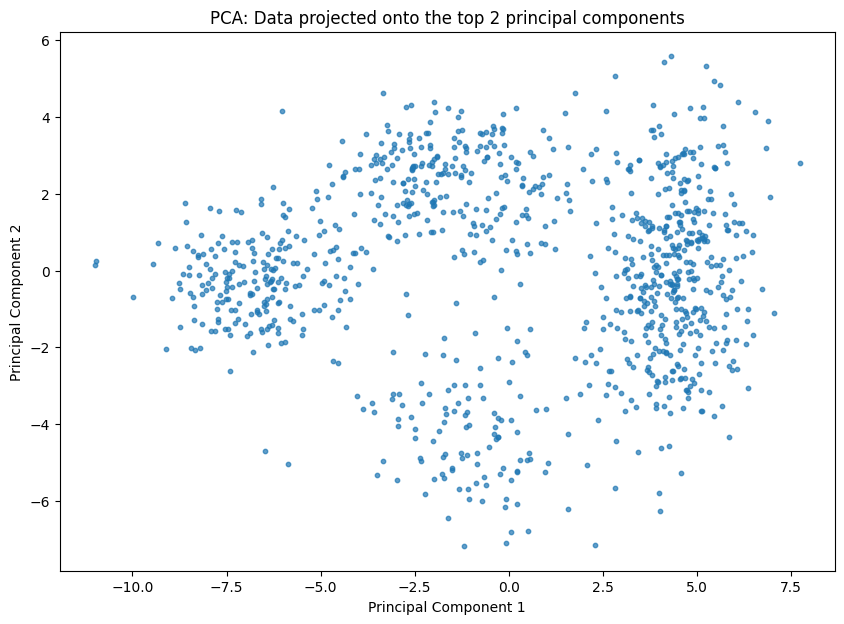

C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


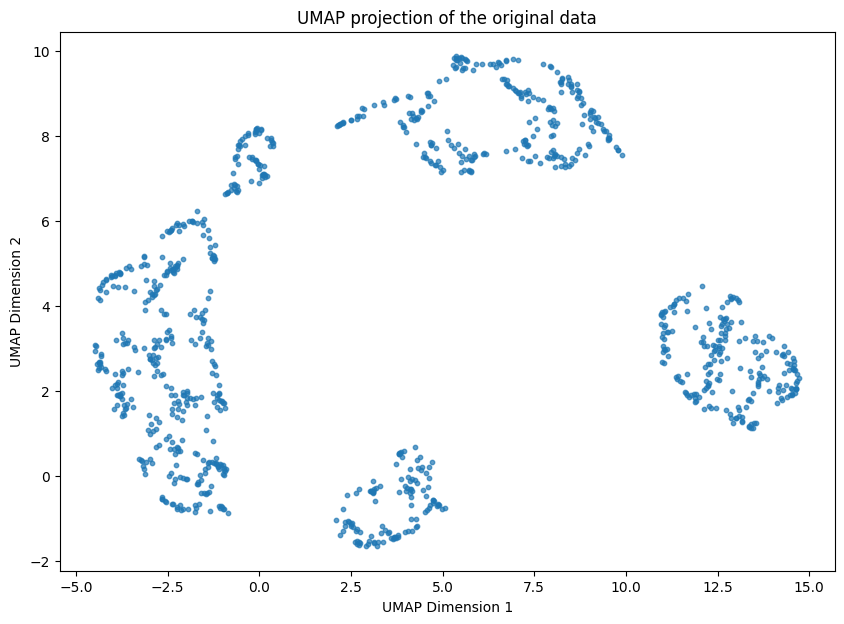

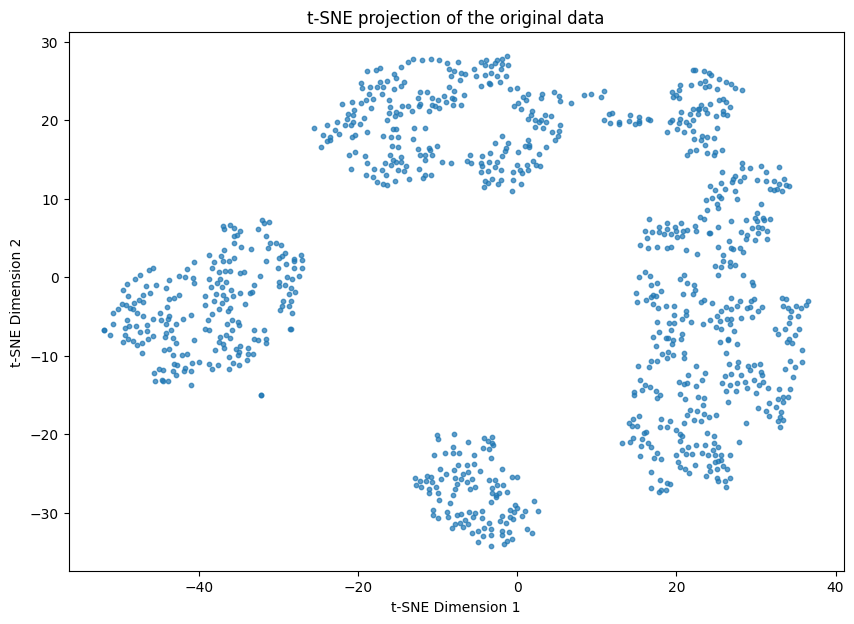

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap

# Step 1: data
data = pd.read_csv("pca_data.txt", sep=" ", header=None)
X = data.values  # Convert DataFrame to NumPy array

# Step 2: data standardization
X_meaned = X - np.mean(X, axis=0)

# Step 3: covariance matrix computation
cov_matrix = np.cov(X_meaned, rowvar=False)

# Step 4: Performing eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Step 5: eigenvalues sorting in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

# Step 6: Selecting the top 2 eigenvectors
top_2_eigenvectors = sorted_eigenvectors[:, :2]

# Step 7: Projecting the data onto the top 2 eigenvectors
X_pca_2d = X_meaned.dot(top_2_eigenvectors)

# Step 8: a 2D scatter plot of the PCA projection
plt.figure(figsize=(10, 7))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], s=10, alpha=0.7)
plt.title("PCA: Data projected onto the top 2 principal components")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# UMAP visualization
umap_2d = umap.UMAP(n_components=2, random_state=42)
X_umap_2d = umap_2d.fit_transform(X)

plt.figure(figsize=(10, 7))
plt.scatter(X_umap_2d[:, 0], X_umap_2d[:, 1], s=10, alpha=0.7)
plt.title("UMAP projection of the original data")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.show()

# t-SNE visualization
tsne_2d = TSNE(n_components=2, random_state=42)
X_tsne_2d = tsne_2d.fit_transform(X)

plt.figure(figsize=(10, 7))
plt.scatter(X_tsne_2d[:, 0], X_tsne_2d[:, 1], s=10, alpha=0.7)
plt.title("t-SNE projection of the original data")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()


# EM Algorithm

In [ ]:
import numpy as np
from scipy.special import factorial

# the dataset
data = np.loadtxt('em_data.txt')

# Initializing parameters
np.random.seed(0)
lambda_with_fp = np.random.rand() * np.mean(data)  # mean for families with family planning advice
lambda_without_fp = np.random.rand() * np.mean(data)  # mean for families without family planning advice
pi_fp = 0.5  # initial proportion of families with family planning advice
pi_no_fp = 1 - pi_fp  # initial proportion of families without family planning advice

# convergence threshold
tolerance = 1e-6
max_iterations = 100
log_likelihood_old = 0

# EM Algorithm
for iteration in range(max_iterations):
    # E-Step:  responsibilities calculation (posterior probabilities)
    prob_with_fp = pi_fp * (np.exp(-lambda_with_fp) * (lambda_with_fp ** data) / factorial(data))
    prob_without_fp = pi_no_fp * (np.exp(-lambda_without_fp) * (lambda_without_fp ** data) / factorial(data))
    
    # Normalize to get responsibilities (weights)
    total_prob = prob_with_fp + prob_without_fp
    r_with_fp = prob_with_fp / total_prob
    r_without_fp = prob_without_fp / total_prob

    # M-Step: The parameters get updated based on the responsibilities
    lambda_with_fp = np.sum(r_with_fp * data) / np.sum(r_with_fp)
    lambda_without_fp = np.sum(r_without_fp * data) / np.sum(r_without_fp)
    pi_fp = np.mean(r_with_fp)
    pi_no_fp = 1 - pi_fp

    # log-likelihood to check for convergence
    log_likelihood = np.sum(np.log(total_prob))
    if abs(log_likelihood - log_likelihood_old) < tolerance:
        print("Convergence reached at iteration:", iteration)
        break
    log_likelihood_old = log_likelihood

print("Estimated mean number of children for families with family planning:", lambda_with_fp)
print("Estimated mean number of children for families without family planning:", lambda_without_fp)
print("Estimated proportion of families with family planning:", pi_fp)
print("Estimated proportion of families without family planning:", pi_no_fp)


Estimated mean number of children for families with family planning: 1.7839622667826571
Estimated mean number of children for families without family planning: 4.912037085130496
Estimated proportion of families with family planning: 0.35646113021025116
Estimated proportion of families without family planning: 0.6435388697897488
